# Vibe Bridge — Validação Experimental (FAISS)
Dataset: `dataset_tratado.csv` (baseado em maharshipandya/spotify-tracks-dataset)

**Correção aplicada:** distância Euclidiana (`IndexFlatL2`) em vez de similaridade de cosseno, porque as features acústicas normalizadas são todas positivas [0,1] e o cosseno concentrava tudo perto de 1.0.

## 1. Instalar bibliotecas

In [1]:
%pip install faiss-cpu pandas numpy scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Confirmar diretório de trabalho

In [2]:
import os
print("Diretório atual:", os.getcwd())
print("Arquivos aqui:", [f for f in os.listdir() if f.endswith(".csv")])

Diretório atual: c:\Users\LAISA\vibe-bridge-projeto
Arquivos aqui: ['dataset.csv', 'dataset_tratado.csv']


## 3. Carregar o dataset

In [3]:
import pandas as pd

df = pd.read_csv("./dataset_tratado.csv")
print(df.shape)
df.head()

(80583, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 4. Conferir colunas

In [4]:
print(df.columns.tolist())

['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


## 5. Normalizar as features (Min-Max)

In [5]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

FEATURES = ["energy", "danceability", "valence", "acousticness", "tempo"]

scaler = MinMaxScaler()
X = scaler.fit_transform(df[FEATURES]).astype("float32")
X.shape

(80583, 5)

## 6. Construir o índice FAISS (CORRIGIDO: L2 em vez de cosseno)
Distância Euclidiana é a métrica correta para features normalizadas sempre positivas.

In [6]:
import faiss

index = faiss.IndexFlatL2(X.shape[1])
index.add(X)
print("Faixas indexadas:", index.ntotal)

Faixas indexadas: 80583


## 7. Diagnóstico: distribuição real das distâncias
Roda isso ANTES de escolher tau, para calibrar com base nos dados reais.

In [7]:
distancias_amostra, _ = index.search(X[42].reshape(1, -1), 1000)
print("Distância mínima:", distancias_amostra.min())
print("Distância máxima (das 1000 mais próximas):", distancias_amostra.max())
print("Percentis:", np.percentile(distancias_amostra, [10, 25, 50, 75, 90]))

Distância mínima: 0.0
Distância máxima (das 1000 mais próximas): 0.0660913
Percentis: [0.02331128 0.0339396  0.0467943  0.05706805 0.0628026 ]


## 8. Funções de busca e ranking (CORRIGIDAS)

In [8]:
def buscar_candidatos(idx_faixa_A, k=10000):
    vetor_A = X[idx_faixa_A].reshape(1, -1)
    distancias, indices = index.search(vetor_A, k)
    d = distancias[0]

    # Normaliza dentro do próprio conjunto de candidatos retornado:
    # o mais próximo vira S=1.0, o mais distante (do k-ésimo) vira S=0.0
    d_min, d_max = d.min(), d.max()
    if d_max - d_min < 1e-9:
        similaridades = np.ones_like(d)
    else:
        similaridades = 1 - (d - d_min) / (d_max - d_min)

    return similaridades, indices[0]


def rankear(idx_faixa_A, tau=0.5, alpha=0.5, k=50):
    sims, idxs = buscar_candidatos(idx_faixa_A, k=k)

    candidatos = df.iloc[idxs].copy()
    candidatos["S"] = sims

    filtrados = candidatos[candidatos["S"] >= tau].copy()
    if filtrados.empty:
        print(f"Aviso: nenhuma faixa atingiu tau={tau}. Mantendo os k={k} candidatos mais próximos.")
        filtrados = candidatos.copy()

    filtrados["P"] = filtrados["popularity"] / 100.0
    filtrados["D"] = 1 - filtrados["P"]
    filtrados["Score"] = alpha * filtrados["S"] + (1 - alpha) * filtrados["D"]

    return filtrados.sort_values("Score", ascending=False)

## 9. Testar com base no diagnóstico da célula 7
Ajuste `tau` para um valor real dentro da faixa de percentis que você viu acima (lembre: aqui é SIMILARIDADE, não distância — quanto maior, mais parecido).

In [9]:
resultado = rankear(idx_faixa_A=42, tau=0.5, alpha=0.5, k=100)
resultado[["track_name", "artists", "S", "P", "D", "Score"]].head(10)

,track_name,artists,S,P,D,Score
44362,Winter Song,Sam Fender,0.828331,0.00,1.00,0.914165
56659,Marry Me (Instrumental Piano Version),Laura Sullivan,0.806960,0.15,0.85,0.828480
66391,Цыганские напевы,Nikolai Erdenko,0.626291,0.00,1.00,0.813146
26,Party of One,Brandi Carlile;Sam Smith,0.596463,0.00,1.00,0.798231
69943,Edges of the World,Michael Cerveris,0.718868,0.25,0.75,0.734434
43906,Naganya Maya,Sajjan Raj Vaidya,0.908110,0.53,0.47,0.689055
70077,The View From Here,Christian Borle;Jake Ryan Flynn,0.598627,0.23,0.77,0.684313
70351,Company - Original Broadway Cast: Someone Is W...,Stephen Sondheim;Dean Jones;Harold Hastings,0.568590,0.20,0.80,0.684295
42,Gravity,Sara Bareilles,1.000000,0.67,0.33,0.665000
69837,"God Rest Ye Merry, Gentlemen",Julie Andrews,0.580024,0.26,0.74,0.660012


## 10. Comparar os 3 modos de recomendação

In [10]:
for nome, alpha in [("Similarity-oriented", 0.8), ("Balanced", 0.5), ("Discovery-oriented", 0.2)]:
    print(f"\n=== {nome} (alpha={alpha}) ===")
    r = rankear(idx_faixa_A=42, tau=0.5, alpha=alpha, k=100)
    print(r[["track_name", "artists", "S", "P", "Score"]].head(5).to_string(index=False))


=== Similarity-oriented (alpha=0.8) ===
                           track_name           artists        S    P    Score
                              Gravity    Sara Bareilles 1.000000 0.67 0.866000
                          Winter Song        Sam Fender 0.828331 0.00 0.862665
                         Naganya Maya Sajjan Raj Vaidya 0.908110 0.53 0.820488
Marry Me (Instrumental Piano Version)    Laura Sullivan 0.806960 0.15 0.815568
                   Edges of the World  Michael Cerveris 0.718868 0.25 0.725094

=== Balanced (alpha=0.5) ===
                           track_name                  artists        S    P    Score
                          Winter Song               Sam Fender 0.828331 0.00 0.914165
Marry Me (Instrumental Piano Version)           Laura Sullivan 0.806960 0.15 0.828480
                     Цыганские напевы          Nikolai Erdenko 0.626291 0.00 0.813146
                         Party of One Brandi Carlile;Sam Smith 0.596463 0.00 0.798231
                   Edges 

## 11. Comparar as 5 estratégias (Seção 15 da Especificação)

In [11]:
def estrategia_popularidade(idx_faixa_A, k=50):
    # Pega as k faixas menos populares do dataset inteiro
    candidatos = df.sort_values("popularity", ascending=True).head(k).copy()
    # Calcula a similaridade REAL delas com a faixa de referência (não força zero)
    vetor_A = X[idx_faixa_A]
    dists = np.linalg.norm(X[candidatos.index] - vetor_A, axis=1)
    candidatos["S"] = 1 / (1 + dists)
    return candidatos


def estrategia_similaridade(idx_faixa_A, k=50):
    sims, idxs = buscar_candidatos(idx_faixa_A, k=k)
    candidatos = df.iloc[idxs].copy()
    candidatos["S"] = sims
    return candidatos.sort_values("S", ascending=False)


def estrategia_sim_mais_pop(idx_faixa_A, k=50):
    sims, idxs = buscar_candidatos(idx_faixa_A, k=k)
    candidatos = df.iloc[idxs].copy()
    candidatos["S"] = sims
    candidatos["P"] = candidatos["popularity"] / 100.0
    candidatos["Score"] = candidatos["S"] + (1 - candidatos["P"])
    return candidatos.sort_values("Score", ascending=False)


def estrategia_descoberta_condicionada(idx_faixa_A, tau=0.5, alpha=0.5, k=50):
    return rankear(idx_faixa_A, tau=tau, alpha=alpha, k=k)


def avaliar_estrategia(nome, resultado_df, top_n=10):
    # Mede só o TOP-N que seria de fato recomendado ao usuário,
    # não o conjunto inteiro retornado pela busca
    topo = resultado_df.head(top_n)
    sim_media = topo["S"].mean() if "S" in topo else float("nan")
    pop_media = (topo["popularity"] / 100.0).mean()
    n_artistas_unicos = topo["artists"].nunique()
    print(f"{nome:35s} | Sim. média (top {top_n}): {sim_media:.3f} | Pop. média: {pop_media:.3f} | Artistas únicos: {n_artistas_unicos}")

In [12]:
idx_teste = 42
k_teste = 10000

r1 = estrategia_popularidade(idx_teste, k=k_teste)
r2 = estrategia_similaridade(idx_teste, k=k_teste)
r3 = estrategia_sim_mais_pop(idx_teste, k=k_teste)
r4 = estrategia_descoberta_condicionada(idx_teste, tau=0.5, alpha=0.5, k=k_teste)

print("="*100)
avaliar_estrategia("1. Popularidade pura", r1)
avaliar_estrategia("2. Similaridade pura", r2)
avaliar_estrategia("3. Similaridade + Popularidade", r3)
avaliar_estrategia("4. Descoberta condicionada (tau=0.5)", r4)
print("="*100)

1. Popularidade pura                | Sim. média (top 10): 0.606 | Pop. média: 0.000 | Artistas únicos: 8
2. Similaridade pura                | Sim. média (top 10): 0.977 | Pop. média: 0.353 | Artistas únicos: 10
3. Similaridade + Popularidade      | Sim. média (top 10): 0.933 | Pop. média: 0.003 | Artistas únicos: 9
4. Descoberta condicionada (tau=0.5) | Sim. média (top 10): 0.933 | Pop. média: 0.003 | Artistas únicos: 9


## 12. Testar diferentes combinações de tau e alpha

In [13]:
import itertools

taus = [0.3, 0.5, 0.7]
alphas = [0.2, 0.5, 0.8]

for tau, alpha in itertools.product(taus, alphas):
    resultado = rankear(idx_faixa_A=42, tau=tau, alpha=alpha, k=100)
    n_candidatos = len(resultado)
    pop_media = resultado["P"].mean() if n_candidatos > 0 else float("nan")
    print(f"tau={tau:.2f}  alpha={alpha:.1f}  ->  {n_candidatos:3d} candidatos  |  pop. média: {pop_media:.3f}")

tau=0.30  alpha=0.2  ->   43 candidatos  |  pop. média: 0.332
tau=0.30  alpha=0.5  ->   43 candidatos  |  pop. média: 0.332
tau=0.30  alpha=0.8  ->   43 candidatos  |  pop. média: 0.332
tau=0.50  alpha=0.2  ->   18 candidatos  |  pop. média: 0.324
tau=0.50  alpha=0.5  ->   18 candidatos  |  pop. média: 0.324


tau=0.50  alpha=0.8  ->   18 candidatos  |  pop. média: 0.324
tau=0.70  alpha=0.2  ->    7 candidatos  |  pop. média: 0.380
tau=0.70  alpha=0.5  ->    7 candidatos  |  pop. média: 0.380
tau=0.70  alpha=0.8  ->    7 candidatos  |  pop. média: 0.380


## 13. Medir latência do FAISS (meta: < 100ms)

In [14]:
import time

n_repeticoes = 100
tempos = []

for _ in range(n_repeticoes):
    idx_aleatorio = np.random.randint(0, X.shape[0])
    inicio = time.perf_counter()
    _ = buscar_candidatos(idx_aleatorio, k=50)
    fim = time.perf_counter()
    tempos.append((fim - inicio) * 1000)

tempos = np.array(tempos)
print(f"Latência média: {tempos.mean():.2f} ms")
print(f"Latência máxima: {tempos.max():.2f} ms")
print(f"Latência p95: {np.percentile(tempos, 95):.2f} ms")
print(f"\nMeta: < 100ms  ->  {'✅ OK' if tempos.mean() < 100 else '❌ Requer índice aproximado'}")

Latência média: 0.21 ms
Latência máxima: 1.54 ms
Latência p95: 0.40 ms

Meta: < 100ms  ->  ✅ OK


## 14. Testar a interpolação vetorial (a Bridge)

In [15]:
def gerar_bridge(idx_A, idx_B, n_pontos=5, k=10000, tau=0.5, alpha=0.5):
    vetor_A = X[idx_A]
    vetor_B = X[idx_B]
    trajetoria = []

    for t in np.linspace(0, 1, n_pontos):
        x_t = (1 - t) * vetor_A + t * vetor_B
        x_t = x_t.reshape(1, -1).astype("float32")

        distancias, idxs = index.search(x_t, k)
        d = distancias[0]
        d_min, d_max = d.min(), d.max()
        sims = 1 - (d - d_min) / (d_max - d_min) if d_max - d_min > 1e-9 else np.ones_like(d)

        candidatos = df.iloc[idxs[0]].copy()
        candidatos["S"] = sims
        candidatos = candidatos[candidatos["S"] >= tau]
        if len(candidatos) == 0:
            continue

        candidatos["P"] = candidatos["popularity"] / 100.0
        candidatos["D"] = 1 - candidatos["P"]
        candidatos["Score"] = alpha * candidatos["S"] + (1 - alpha) * candidatos["D"]

        melhor = candidatos.sort_values("Score", ascending=False).iloc[0]

        # Mede a similaridade do candidato escolhido em relação às faixas A e B ORIGINAIS
        # (não em relação a x(t)) — isso é o que prova a transição de verdade
        idx_melhor = melhor.name
        dist_para_A = np.linalg.norm(X[idx_melhor] - vetor_A)
        dist_para_B = np.linalg.norm(X[idx_melhor] - vetor_B)
        sim_para_A = 1 / (1 + dist_para_A)
        sim_para_B = 1 / (1 + dist_para_B)

        melhor["S_para_A"] = sim_para_A
        melhor["S_para_B"] = sim_para_B
        trajetoria.append((t, melhor))

    return trajetoria


idx_A, idx_B = 42, 1000
trajetoria = gerar_bridge(idx_A, idx_B, n_pontos=5, tau=0.3, alpha=0.5)

for t, faixa in trajetoria:
    print(f"t={t:.2f}  |  {faixa['track_name']} — {faixa['artists']}  "
          f"(S→A={faixa['S_para_A']:.3f}, S→B={faixa['S_para_B']:.3f}, P={faixa['P']:.3f})")

t=0.00  |  Winter Song — Sam Fender  (S→A=0.941, S→B=0.478, P=0.000)
t=0.25  |  Mandolin Concerto in C Major, RV 425: III. Allegro — Antonio Vivaldi;Avi Avital;Venice Baroque Orchestra  (S→A=0.827, S→B=0.526, P=0.000)
t=0.50  |  Sail On — Commodores  (S→A=0.640, S→B=0.646, P=0.000)
t=0.75  |  greatestlove — Musiq Soulchild  (S→A=0.557, S→B=0.763, P=0.000)
t=1.00  |  Casi Nada — KAROL G  (S→A=0.469, S→B=0.952, P=0.000)


## 15. Dashboard final — painel com todos os testes

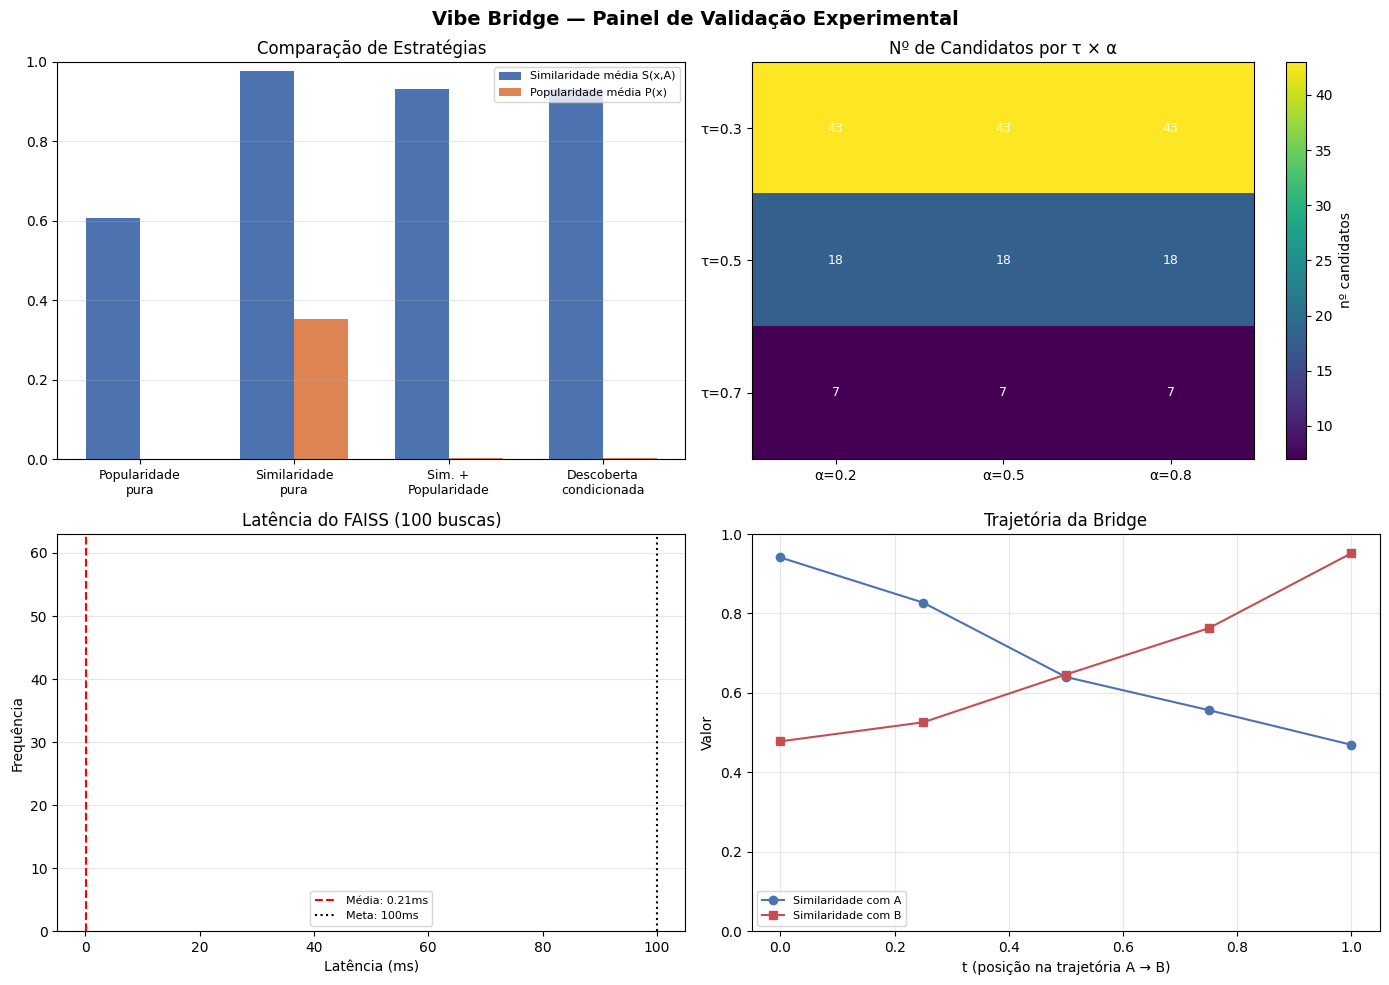

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Vibe Bridge — Painel de Validação Experimental", fontsize=14, fontweight="bold")

ax1 = axes[0, 0]
estrategias = {
    "Popularidade\npura": r1,
    "Similaridade\npura": r2,
    "Sim. +\nPopularidade": r3,
    "Descoberta\ncondicionada": r4,
}
nomes = list(estrategias.keys())
TOP_N = 10
sim_medias = [estrategias[n]["S"].head(TOP_N).mean() if "S" in estrategias[n] else 0 for n in nomes]
pop_medias = [(estrategias[n]["popularity"] / 100.0).head(TOP_N).mean() for n in nomes]

x_pos = np.arange(len(nomes))
largura = 0.35
ax1.bar(x_pos - largura/2, sim_medias, largura, label="Similaridade média S(x,A)", color="#4C72B0")
ax1.bar(x_pos + largura/2, pop_medias, largura, label="Popularidade média P(x)", color="#DD8452")
ax1.set_xticks(x_pos)
ax1.set_xticklabels(nomes, fontsize=9)
ax1.set_ylim(0, 1)
ax1.set_title("Comparação de Estratégias")
ax1.legend(fontsize=8)
ax1.grid(axis="y", alpha=0.3)

ax2 = axes[0, 1]
matriz_candidatos = np.zeros((len(taus), len(alphas)))
for i, tau in enumerate(taus):
    for j, alpha in enumerate(alphas):
        r = rankear(idx_faixa_A=42, tau=tau, alpha=alpha, k=100)
        matriz_candidatos[i, j] = len(r)

im = ax2.imshow(matriz_candidatos, cmap="viridis", aspect="auto")
ax2.set_xticks(range(len(alphas)))
ax2.set_xticklabels([f"α={a}" for a in alphas])
ax2.set_yticks(range(len(taus)))
ax2.set_yticklabels([f"τ={t}" for t in taus])
ax2.set_title("Nº de Candidatos por τ × α")
for i in range(len(taus)):
    for j in range(len(alphas)):
        ax2.text(j, i, int(matriz_candidatos[i, j]), ha="center", va="center", color="white", fontsize=9)
plt.colorbar(im, ax=ax2, label="nº candidatos")

ax3 = axes[1, 0]
ax3.hist(tempos, bins=20, color="#55A868", edgecolor="white")
ax3.axvline(tempos.mean(), color="red", linestyle="--", label=f"Média: {tempos.mean():.2f}ms")
ax3.axvline(100, color="black", linestyle=":", label="Meta: 100ms")
ax3.set_xlabel("Latência (ms)")
ax3.set_ylabel("Frequência")
ax3.set_title("Latência do FAISS (100 buscas)")
ax3.legend(fontsize=8)
ax3.grid(axis="y", alpha=0.3)

ax4 = axes[1, 1]
ts = [t for t, _ in trajetoria]
s_para_a = [faixa["S_para_A"] for _, faixa in trajetoria]
s_para_b = [faixa["S_para_B"] for _, faixa in trajetoria]
ax4.plot(ts, s_para_a, marker="o", label="Similaridade com A", color="#4C72B0")
ax4.plot(ts, s_para_b, marker="s", label="Similaridade com B", color="#C44E52")
ax4.set_xlabel("t (posição na trajetória A → B)")
ax4.set_ylabel("Valor")
ax4.set_ylim(0, 1)
ax4.set_title("Trajetória da Bridge")
ax4.legend(fontsize=8)
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("vibe_bridge_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

## 16. Gráficos individuais — análise detalhada

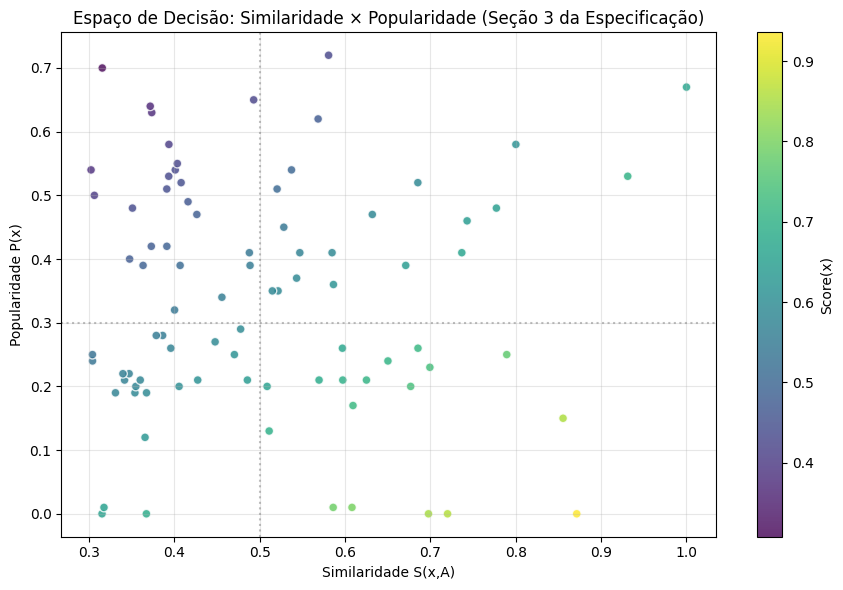

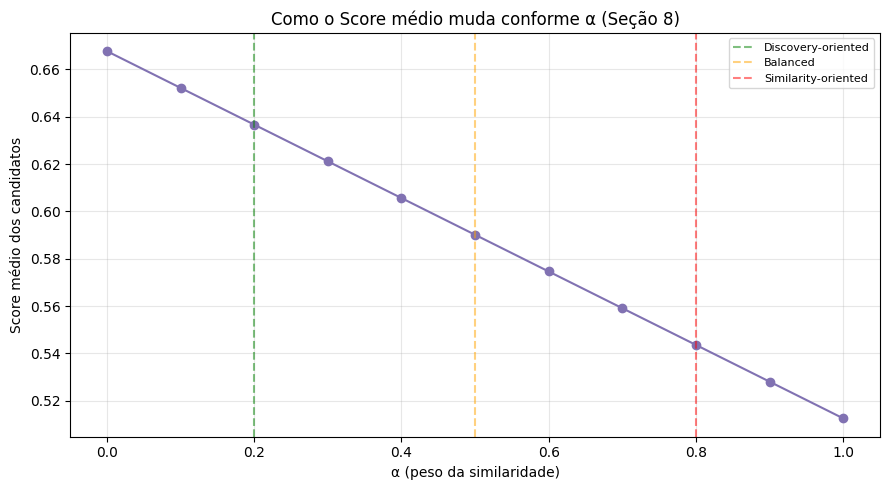

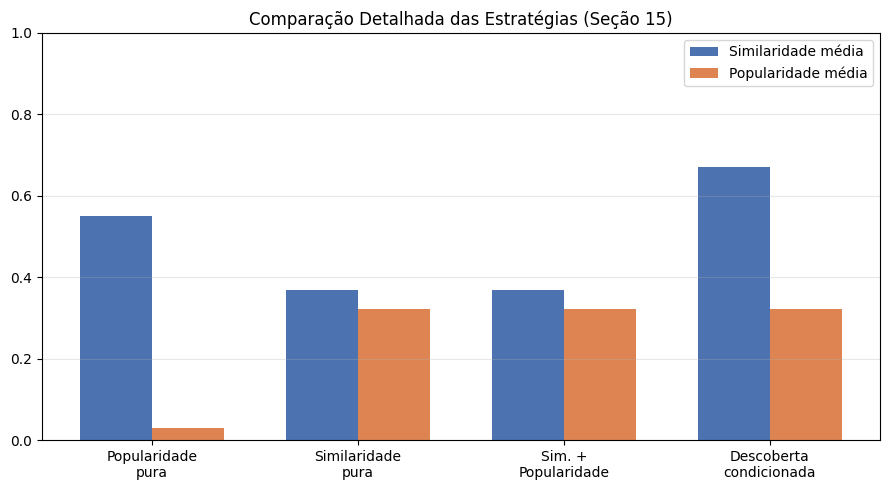

In [17]:
import matplotlib.pyplot as plt

# ---------- Gráfico 1: Dispersão S(x,A) vs P(x) dos candidatos ----------
resultado_scatter = rankear(idx_faixa_A=42, tau=0.3, alpha=0.5, k=200)

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    resultado_scatter["S"], resultado_scatter["P"],
    c=resultado_scatter["Score"], cmap="viridis", s=40, edgecolor="white", alpha=0.8
)
plt.colorbar(scatter, label="Score(x)")
plt.xlabel("Similaridade S(x,A)")
plt.ylabel("Popularidade P(x)")
plt.title("Espaço de Decisão: Similaridade × Popularidade (Seção 3 da Especificação)")
plt.axhline(0.3, color="gray", linestyle=":", alpha=0.5)
plt.axvline(0.5, color="gray", linestyle=":", alpha=0.5)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("grafico_espaco_decisao.png", dpi=150, bbox_inches="tight")
plt.show()

# ---------- Gráfico 2: Score médio por alpha (evolução dos modos) ----------
alphas_teste = np.linspace(0, 1, 11)
scores_medios = []

for alpha in alphas_teste:
    r = rankear(idx_faixa_A=42, tau=0.3, alpha=alpha, k=100)
    scores_medios.append(r["Score"].mean())

plt.figure(figsize=(9, 5))
plt.plot(alphas_teste, scores_medios, marker="o", color="#8172B2")
plt.axvline(0.2, color="green", linestyle="--", alpha=0.5, label="Discovery-oriented")
plt.axvline(0.5, color="orange", linestyle="--", alpha=0.5, label="Balanced")
plt.axvline(0.8, color="red", linestyle="--", alpha=0.5, label="Similarity-oriented")
plt.xlabel("α (peso da similaridade)")
plt.ylabel("Score médio dos candidatos")
plt.title("Como o Score médio muda conforme α (Seção 8)")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("grafico_score_por_alpha.png", dpi=150, bbox_inches="tight")
plt.show()

# ---------- Gráfico 3: Barras comparando as 4 estratégias lado a lado ----------
fig, ax = plt.subplots(figsize=(9, 5))
estrategias_nomes = ["Popularidade\npura", "Similaridade\npura", "Sim. +\nPopularidade", "Descoberta\ncondicionada"]
sim_vals = [r1["S"].mean() if "S" in r1 else 0, r2["S"].mean(), r3["S"].mean(), r4["S"].mean()]
pop_vals = [(r1["popularity"]/100).mean(), (r2["popularity"]/100).mean(), (r3["popularity"]/100).mean(), (r4["popularity"]/100).mean()]

x = np.arange(len(estrategias_nomes))
w = 0.35
ax.bar(x - w/2, sim_vals, w, label="Similaridade média", color="#4C72B0")
ax.bar(x + w/2, pop_vals, w, label="Popularidade média", color="#DD8452")
ax.set_xticks(x)
ax.set_xticklabels(estrategias_nomes)
ax.set_ylim(0, 1)
ax.set_title("Comparação Detalhada das Estratégias (Seção 15)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("grafico_comparacao_estrategias.png", dpi=150, bbox_inches="tight")
plt.show()